# End-to-End GRPO Pipeline (OpenEnv + Unsloth + TRL)

This notebook trains a qwen3.5 0.8B to learn from the energy grid env in order to be able to take decisions regarding grid management



Also, it is necesary that the notebook env has access to the client.py, inference.py and models.py that are availble through github and hfspace or you can clone the entire repo using the cell below


In [1]:
!pip -q install --upgrade unsloth trl transformers datasets accelerate peft bitsandbytes huggingface_hub "openenv-core[core]>=0.2.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The next step is to setup the config for training

In [2]:
import os

# --- Required ---
MODEL_ID = "Qwen/Qwen3.5-0.8B"
ENV_SPACE_URL = "https://mhussain17-energy-grid-env.hf.space"  # change this

# HF token (set in Colab/Notebook secrets or env var)
HF_TOKEN = os.environ.get("HF_TOKEN", "")

# If MODEL_ID is adapter-only and fails to load directly, set base model here.
BASE_MODEL_ID = "Qwen/Qwen3.5-0.8B"

# --- Training/output ---
# Checkpoints + final save go here. On Colab, mount Drive and use My Drive.
USE_GOOGLE_DRIVE = True
GOOGLE_DRIVE_SUBDIR = "energy_grid_rl/grpo_openenv"  # folder under My Drive

LOCAL_OUTPUT_DIR = "outputs/grpo_openenv"
OUTPUT_DIR = LOCAL_OUTPUT_DIR

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)
        OUTPUT_DIR = os.path.join("/content/drive/MyDrive", GOOGLE_DRIVE_SUBDIR)
        print("Checkpoints will save to Google Drive:", OUTPUT_DIR)
    except ImportError:
        print("Not running in Colab (no google.colab); using local folder:", LOCAL_OUTPUT_DIR)
        OUTPUT_DIR = LOCAL_OUTPUT_DIR
else:
    OUTPUT_DIR = LOCAL_OUTPUT_DIR

OUTPUT_MODEL_ID = "MHussain17/sft-qwen-grpo-openenv"  # change if needed
PUSH_TO_HUB = True

# Checkpoint frequency (used by GRPOConfig below)
SAVE_EVERY_STEPS = 30

# --- GRPO data collection ---
PROMPT_EPISODES = 400
MAX_EPISODE_STEPS = 24
SEED = 42

# --- Sequence/VRAM knobs ---
MAX_SEQ_LENGTH = 512
LOAD_IN_4BIT = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR =", OUTPUT_DIR)
print("Config loaded")
OUTPUT_MODEL_ID = "MHussain17/sft-qwen-grpo-openenv"  # change if needed
PUSH_TO_HUB = True

# --- GRPO data collection ---
PROMPT_EPISODES = 60
MAX_EPISODE_STEPS = 24
SEED = 42

# --- Sequence/VRAM knobs ---
MAX_SEQ_LENGTH = 512
LOAD_IN_4BIT = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config loaded")

Mounted at /content/drive
Checkpoints will save to Google Drive: /content/drive/MyDrive/energy_grid_rl/grpo_openenv
OUTPUT_DIR = /content/drive/MyDrive/energy_grid_rl/grpo_openenv
Config loaded
Config loaded


Now we setup all the necessary dependencies along with a regex to strip the action performed by the llm (for eval later)

In [4]:
from unsloth import FastLanguageModel
import random
import re
import numpy as np
from datasets import Dataset
from huggingface_hub import login, list_repo_files
from peft import PeftModel

from trl import GRPOConfig, GRPOTrainer

from client import EnergyGridEnv
from models import GridAction

try:
    from inference import _SYSTEM_PROMPT, _heuristic_action
except Exception:
    _SYSTEM_PROMPT = (
        "You are an expert energy grid dispatch operator managing a 500kW microgrid. "
        "Output one action in this exact format: ### Action: [bess, hospital, industrial, residential]."
    )

    def _heuristic_action(obs):
        # Fallback simple heuristic
        return {"bess": 0, "hospital": 0, "industrial": 0, "residential": 0}

if HF_TOKEN:
    login(token=HF_TOKEN)
    print("HF login: ok")
else:
    print("HF_TOKEN not set (ok if model is public and you do not push).")

def format_prompt(obs):
    vec = [round(v, 3) for v in obs.to_vector()]
    user_prompt = (
        f"Obs vector (22 values): {vec}\n"
        f"solar_swan={obs.solar_swan_active:.0f} wind_swan={obs.wind_swan_active:.0f} "
        f"soc={obs.battery_soc:.2f} freq_norm={obs.frequency_norm:.3f}\n"
        f"hosp_ratio={obs.hosp_served_ratio:.3f} ind_ratio={obs.ind_served_ratio:.3f} "
        f"res_ratio={obs.res_served_ratio:.3f}\n"
        "What is your dispatch decision?"
    )
    return _SYSTEM_PROMPT + "\n\n" + user_prompt

ACTION_RE = re.compile(r"###\s*Action:\s*\[(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\]")

def completion_to_text(c):
    # TRL can pass plain strings or chat-format lists.
    if isinstance(c, str):
        return c
    if isinstance(c, list):
        parts = []
        for msg in c:
            if isinstance(msg, dict) and "content" in msg:
                parts.append(str(msg["content"]))
        return "\n".join(parts)
    return str(c)

def parse_action(text):
    m = ACTION_RE.search(text)
    if not m:
        return None
    b, h, i, r = [int(x) for x in m.groups()]
    if not (0 <= b <= 5 and 0 <= h <= 1 and 0 <= i <= 3 and 0 <= r <= 3):
        return None
    return GridAction(bess=b, hospital=h, industrial=i, residential=r)

HF_TOKEN not set (ok if model is public and you do not push).


Instantiate the EnergyGridEnv

In [5]:
# Quick OpenEnv connectivity check (latest docs pattern: .sync() in notebooks)
with EnergyGridEnv(base_url=ENV_SPACE_URL).sync() as env:
    result = env.reset(seed=SEED, scenario=0)
    obs = result.observation
    act = _heuristic_action(obs)
    result2 = env.step(GridAction(**act))
    print("Reset+step ok | reward:", result2.reward, "done:", result2.done)

Reset+step ok | reward: 135.2721 done: False


Building a GRPO dataset for sft and validation

In [6]:
def build_grpo_prompt_dataset(episodes=PROMPT_EPISODES, max_steps=MAX_EPISODE_STEPS, seed=SEED):
    rng = random.Random(seed)
    rows = []
    scenarios = [0, 1, 2, 3, 4]

    with EnergyGridEnv(base_url=ENV_SPACE_URL).sync() as env:
        for ep in range(episodes):
            scenario = scenarios[ep % len(scenarios)]
            episode_seed = seed + ep * 19

            result = env.reset(seed=episode_seed, scenario=scenario)
            obs = result.observation

            for step_idx in range(max_steps):
                rows.append(
                    {
                        "prompt": format_prompt(obs),
                        "seed": int(episode_seed),
                        "scenario": int(scenario),
                        "step_idx": int(step_idx),
                    }
                )

                # Advance to next state using heuristic to cover realistic state manifold.
                action_dict = _heuristic_action(obs)
                result = env.step(GridAction(**action_dict))
                obs = result.observation
                if result.done:
                    break

            if (ep + 1) % 50 == 0:
                print(f"Collected episodes: {ep + 1}/{episodes} | prompts so far: {len(rows)}")

    rng.shuffle(rows)
    ds = Dataset.from_list(rows)
    print(ds)
    return ds

train_dataset = build_grpo_prompt_dataset()
train_dataset[0]

Collected episodes: 50/60 | prompts so far: 1200
Dataset({
    features: ['prompt', 'seed', 'scenario', 'step_idx'],
    num_rows: 1440
})


{'prompt': 'You are an expert energy grid dispatch operator managing a 500kW microgrid. Output one action in this exact format: ### Action: [bess, hospital, industrial, residential].\n\nObs vector (22 values): [0.966, -0.259, 0.136, 0.475, 0.508, 1.0, 0.209, 1.0, 0.559, 1.0, 0.399, 1.0, 0.497, 0.971, 0.0, 0.0, 0.333, 0.012, 0.0, 0.0, 0.0, 0.0]\nsolar_swan=0 wind_swan=0 soc=0.51 freq_norm=0.497\nhosp_ratio=1.000 ind_ratio=1.000 res_ratio=1.000\nWhat is your dispatch decision?',
 'seed': 669,
 'scenario': 3,
 'step_idx': 8}

Load the model and instantiate it

In [7]:
def load_model_for_grpo(model_id=MODEL_ID, base_model_id=BASE_MODEL_ID):
    files = set(list_repo_files(model_id))
    is_adapter_only = "adapter_config.json" in files

    if is_adapter_only:
        print(f"{model_id} appears adapter-only; loading base {base_model_id} then adapter.")
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=base_model_id,
            max_seq_length=MAX_SEQ_LENGTH,
            load_in_4bit=LOAD_IN_4BIT,
        )
        model = PeftModel.from_pretrained(model, model_id)
    else:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_id,
            max_seq_length=MAX_SEQ_LENGTH,
            load_in_4bit=LOAD_IN_4BIT,
        )

    # If no trainable adapters are present, attach LoRA adapters for GRPO updates.
    if not hasattr(model, "peft_config"):
        model = FastLanguageModel.get_peft_model(
            model,
            r=8,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            lora_alpha=16,
            lora_dropout=0.0,
            bias="none",
            use_gradient_checkpointing="unsloth",
            random_state=SEED,
        )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    return model, tokenizer

model, tokenizer = load_model_for_grpo()
print("Model loaded")

==((====))==  Unsloth 2026.4.8: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Model loaded


Define the reward for training

In [8]:
def env_reward(completions, **kwargs):
    rewards = []
    for comp_text in completions:
        score = 0.0

        # Reward 1: Did it at least START the tag? (+50)
        if "### Action:" in comp_text:
            score += 50.0

        # Reward 2: Did it include any numbers in brackets? (+50)
        if re.search(r"\[\d+", comp_text):
            score += 50.0

        # Reward 3: Environment Performance (The big win)
        action = parse_action(comp_text)
        if action:
            # Replay and step...
            result = env.step(action)
            score += float(result.reward)
        else:
            # Truncation penalty is smaller than format failure
            score -= 100.0 if "### Action:" in comp_text else 300.0

        rewards.append(score)
    return rewards

Shuffle and select random 1200 samples from the dataset (the size was reduce to cater to time constraints of the competition)

In [9]:
# In your notebook logic:
 # Reduces prompts to ~1200
# OR
train_dataset = train_dataset.shuffle(seed=42).select(range(1200))

Train the model using params optimized for speed (time constraint) and compute (google collab free tier)

In [10]:
# T4-safe GRPO defaults; reduce num_generations/max_completion_length if OOM.
# Checkpoints: every SAVE_EVERY_STEPS (30) to OUTPUT_DIR (Google Drive on Colab if USE_GOOGLE_DRIVE).
grpo_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=1e-5,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,          # Increased for RL stability
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,           # Log every step for better reward curves
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4, # INCREASED: Stabilizes small batch sizes
    num_generations=2,         # KEPT: Essential for T4 VRAM/Speed
    max_prompt_length=320,
    max_completion_length=400, # REDUCED: Prevents "rambling" and timeouts
    max_steps=120,             # TARGETED: Ensure completion + README prep
    save_strategy="steps",
    save_steps=30,
    save_total_limit=2,        # REDUCED: Avoids filling up disk space
    max_grad_norm=1.0,         # Standardized: 0.1 was too restrictive
    fp16=True,
     # REQUIRED: Prevents vLLM from hogging RAM
    report_to="none",
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[env_reward],
    args=grpo_args,
    train_dataset=train_dataset,
)

train_result = trainer.train()
train_result

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.


Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,200 | Num Epochs = 1 | Total steps = 120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 3,194,880 of 856,180,800 (0.37% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / env_reward / mean,rewards / env_reward / std
1,-0.087906,-68.750000,61.871849,163.500000,12.000000,400.000000,0.250000,84.666672,12.000000,219.000000,0.000017,-68.750000,96.130493
2,0.043265,-100.000000,106.066025,367.375000,139.000000,400.000000,0.875000,139.000000,139.000000,139.000000,0.000012,-100.000000,125.356636
3,0.025963,-168.750000,79.549515,305.500000,73.000000,400.000000,0.625000,148.000000,73.000000,234.000000,0.000011,-168.750000,127.999725
4,-0.095986,-93.750000,8.838835,340.000000,8.000000,400.000000,0.750000,160.000000,8.000000,312.000000,0.000014,-93.750000,97.970482
5,-0.276413,-125.000000,141.421356,314.000000,1.000000,400.000000,0.750000,56.000000,1.000000,111.000000,0.000019,-125.000000,133.630630
6,0.138023,-187.500000,123.743690,316.000000,15.000000,400.000000,0.750000,64.000000,15.000000,113.000000,0.000017,-187.500000,115.727516
7,0.000000,-106.250000,8.838835,358.750000,70.000000,400.000000,0.875000,70.000000,70.000000,70.000000,0.000015,-106.250000,120.823074
8,-0.146360,-43.750000,8.838835,261.750000,12.000000,400.000000,0.625000,31.333334,12.000000,69.000000,0.000040,-43.750000,17.677670
9,-0.058925,-168.750000,79.549515,252.250000,1.000000,400.000000,0.625000,6.000000,1.000000,12.000000,0.000173,-168.750000,127.999725
10,0.007225,-62.500000,53.033012,294.750000,13.000000,400.000000,0.625000,119.333336,13.000000,328.000000,0.000069,-62.500000,79.056946


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/energy_grid_rl/grpo_openenv/checkpoint-30/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/energy_grid_rl/grpo_openenv/checkpoint-60/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/energy_grid_rl/grpo_openenv/checkpoint-90/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/energy_grid_rl/grpo_openenv/checkpoint-120/tokenizer_config.json.


TrainOutput(global_step=120, training_loss=-0.031841132400284716, metrics={'train_runtime': 9481.9938, 'train_samples_per_second': 0.101, 'train_steps_per_second': 0.013, 'total_flos': 0.0, 'train_loss': -0.031841132400284716})

Plotting the training and validation loss

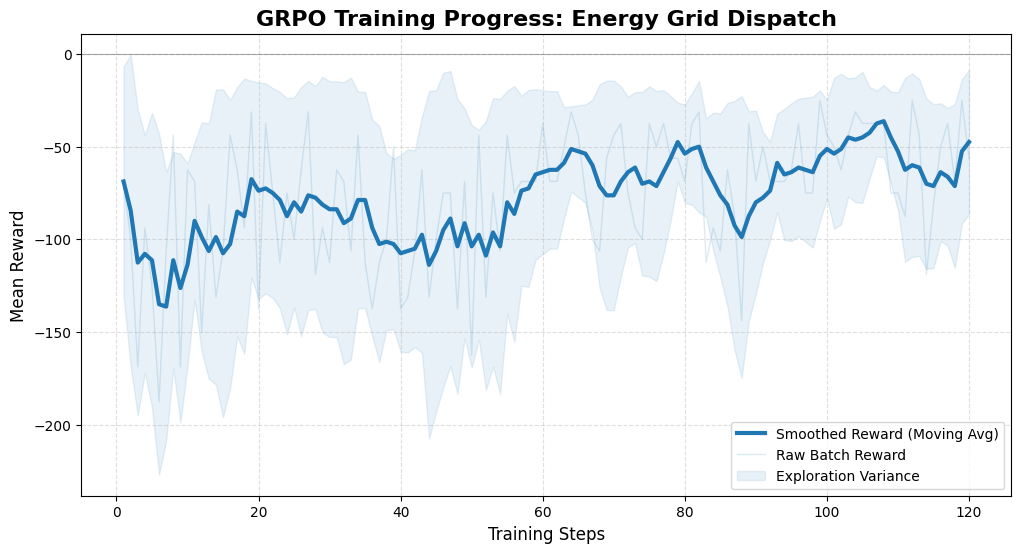

✅ Professional smoothed curve generated as 'reward_curve_clean.png'.


In [15]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# Load the logs we saved to Drive
LOG_PATH = "/content/drive/My Drive/energy_grid_rl/grpo_openenv/checkpoint-120/trainer_state.json"

with open(LOG_PATH, "r") as f:
    data = json.load(f)

# Convert to DataFrame
if isinstance(data, dict) and "log_history" in data:
    logs = data["log_history"]
else:
    logs = data

# Convert to DataFrame and filter for actual training steps (exclude final summary logs)
# Convert to DataFrame and filter for actual training steps
df = pd.DataFrame(logs)
df = df.dropna(subset=["reward", "step"])

# --- SMOOTHING LOGIC ---
# Apply a moving average to make the trend clearer for the presentation
window_size = 5
df["reward_smooth"] = df["reward"].rolling(window=window_size, min_periods=1).mean()
df["std_smooth"] = df["reward_std"].rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(12, 6))

# Plot the smoothed mean
plt.plot(df["step"], df["reward_smooth"], label="Smoothed Reward (Moving Avg)", color="#1f77b4", linewidth=3)

# Plot the raw reward with low alpha to show the "real" noise behind the scenes
plt.plot(df["step"], df["reward"], color="#1f77b4", alpha=0.15, linewidth=1, label="Raw Batch Reward")

# Fill standard deviation (smoothed)
if "reward_std" in df.columns:
    plt.fill_between(df["step"],
                     df["reward_smooth"] - df["std_smooth"],
                     df["reward_smooth"] + df["std_smooth"],
                     alpha=0.1, color="#1f77b4", label="Exploration Variance")

# Professional styling
plt.title("GRPO Training Progress: Energy Grid Dispatch", fontsize=16, fontweight='bold')
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Mean Reward", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc="lower right")

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# Save for the README
plt.savefig("reward_curve_clean.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Professional smoothed curve generated as 'reward_curve_clean.png'.")

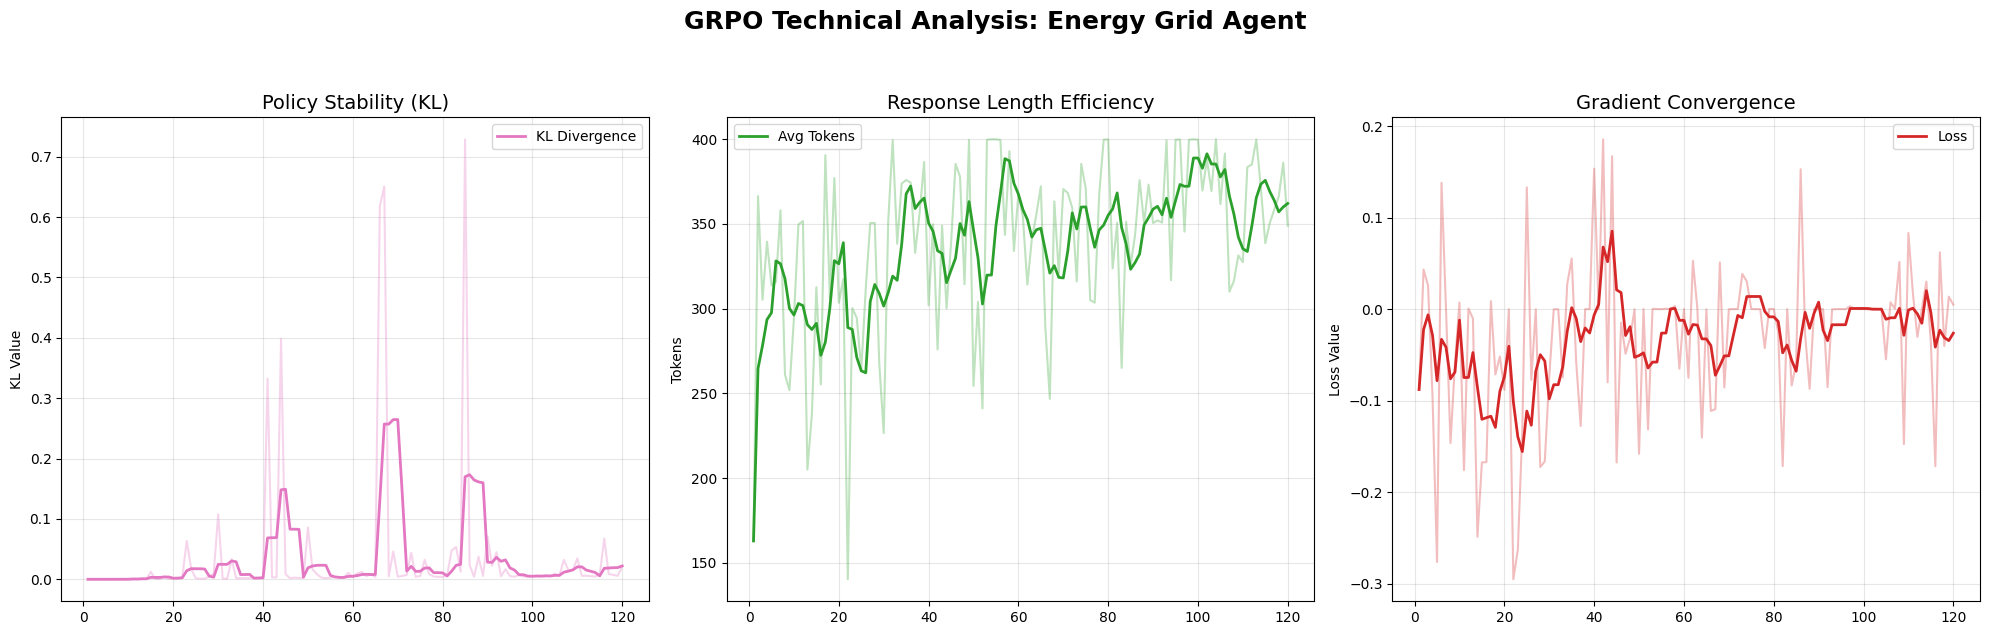

✅ Technical dashboard generated as 'technical_dashboard.png'.


In [16]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Path to your persistent logs
LOG_PATH = "/content/drive/My Drive/energy_grid_rl/grpo_openenv/checkpoint-120/trainer_state.json"

with open(LOG_PATH, "r") as f:
    data = json.load(f)

logs = data.get("log_history", data)
df = pd.DataFrame(logs)

# Clean and split metrics
# Training metrics usually have 'step', 'loss', 'kl', etc.
train_df = df.dropna(subset=["step", "kl", "loss", "completion_length"])

def smooth(series, window=5):
    return series.rolling(window=window, min_periods=1).mean()

# Create a 3-panel professional dashboard
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("GRPO Technical Analysis: Energy Grid Agent", fontsize=18, fontweight='bold', y=1.05)

# Panel 1: KL Divergence (Policy Stability)
axes[0].plot(train_df["step"], train_df["kl"], color="#e377c2", alpha=0.3)
axes[0].plot(train_df["step"], smooth(train_df["kl"]), color="#e377c2", linewidth=2, label="KL Divergence")
axes[0].set_title("Policy Stability (KL)", fontsize=14)
axes[0].set_ylabel("KL Value")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: Completion Length (Efficiency)
axes[1].plot(train_df["step"], train_df["completion_length"], color="#2ca02c", alpha=0.3)
axes[1].plot(train_df["step"], smooth(train_df["completion_length"]), color="#2ca02c", linewidth=2, label="Avg Tokens")
axes[1].set_title("Response Length Efficiency", fontsize=14)
axes[1].set_ylabel("Tokens")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Panel 3: Training Loss
axes[2].plot(train_df["step"], train_df["loss"], color="#d62728", alpha=0.3)
axes[2].plot(train_df["step"], smooth(train_df["loss"]), color="#d62728", linewidth=2, label="Loss")
axes[2].set_title("Gradient Convergence", fontsize=14)
axes[2].set_ylabel("Loss Value")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig("technical_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Technical dashboard generated as 'technical_dashboard.png'.")

In [ ]:
# T4-safe GRPO defaults; reduce num_generations/max_completion_length if OOM.
grpo_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=1e-5,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    num_generations=4,
    max_prompt_length=320,
    max_completion_length=160,
    max_steps=400,
    save_steps=100,
    max_grad_norm=0.1,
    bf16=False,
    report_to="none",
    push_to_hub=False,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[env_reward],
    args=grpo_args,
    train_dataset=train_dataset,
)

train_result = trainer.train()
train_result

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Switching to float32 training since model cannot work with float16


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,600 | Num Epochs = 1 | Total steps = 400
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 3,194,880 of 856,180,800 (0.37% trained)


ValueError: Failed to install environment from HuggingFace Space: mhussain17/energy-grid-env
Command: uv pip install git+https://huggingface.co/spaces/mhussain17/energy-grid-env
Error: Using Python 3.12.13 environment at: /usr
error: Git operation failed
  Caused by: failed to fetch into: /root/.cache/uv/git-v0/db/41f3bbdf0cf67f41
  Caused by: process didn't exit successfully: `/usr/bin/git fetch --force --update-head-ok 'https://huggingface.co/spaces/mhussain17/energy-grid-env' '+HEAD:refs/remotes/origin/HEAD'` (exit status: 128)
--- stderr
fatal: could not read Username for 'https://huggingface.co': terminal prompts disabled

Make sure the repository exists and contains a valid Python package.

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved local artifacts to", OUTPUT_DIR)

if PUSH_TO_HUB:
    # For Unsloth, pushing merged LoRA format is a practical default.
    model.push_to_hub_merged(
        OUTPUT_MODEL_ID,
        tokenizer,
        save_method="lora",
        token=HF_TOKEN if HF_TOKEN else None,
    )
    print("Pushed to Hub:", OUTPUT_MODEL_ID)

In [ ]:
# Optional: one rollout with the trained policy for sanity check.
from transformers import TextStreamer

def generate_action(obs):
    prompt = format_prompt(obs)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
    )
    txt = tokenizer.decode(out[0], skip_special_tokens=True)
    action = parse_action(txt)
    if action is None:
        action = GridAction(bess=0, hospital=0, industrial=0, residential=0)
    return action, txt

episode_reward = 0.0
with EnergyGridEnv(base_url=ENV_SPACE_URL).sync() as env:
    result = env.reset(seed=123, scenario=2)
    obs = result.observation

    for t in range(24):
        action, raw = generate_action(obs)
        result = env.step(action)
        obs = result.observation
        r = float(result.reward if result.reward is not None else 0.0)
        episode_reward += r
        print(f"step={t+1:02d} action={[action.bess, action.hospital, action.industrial, action.residential]} reward={r:.3f} done={result.done}")
        if result.done:
            break

print("Episode reward:", round(episode_reward, 3))

## Notes

- If GPU memory is tight, lower `num_generations` to `2` and `max_completion_length` to `96`.
- If training is slow due to remote reward calls, reduce `PROMPT_EPISODES` and `max_steps` initially.
- For stronger RL, you can increase `PROMPT_EPISODES` and `max_steps` once the pipeline is stable.